In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

def alpha_fractal_function(X, f_vals, g_vals, in_alpha, n_iter):

    X = np.asarray(X, dtype=float)
    f_vals = np.asarray(f_vals, dtype=float)
    g_vals = np.asarray(g_vals, dtype=float)

    N = len(X) - 1

    if len(f_vals) != len(X):
        raise ValueError("f_vals must have the same length as X.")
    if len(g_vals) != len(X):
        raise ValueError("g_vals must have the same length as X.")

    if type(in_alpha) is float:
        alpha = np.full(N, in_alpha)
    else:
        alpha = np.asarray(in_alpha, dtype=float)

    if len(alpha) != N:
        raise ValueError("alpha must have length len(X)-1.")

    x0, xN = X[0], X[-1]
    y0, yN = f_vals[0], f_vals[-1]

    # endpoint values of base function
    g0, gN = g_vals[0], g_vals[-1]

    # Coefficients of L_i(x) = a_i x + b_i
    a = np.zeros(N)
    b = np.zeros(N)

    # Coefficients of F_i(x, y) = alpha_i y + c_i x + d_i
    c = np.zeros(N)
    d = np.zeros(N)

    for i in range(N):
        xi0 = X[i]
        xi1 = X[i + 1]

        fi0 = f_vals[i]
        fi1 = f_vals[i + 1]

        a[i] = (xi1 - xi0) / (xN - x0)
        b[i] = (xN * xi0 - x0 * xi1) / (xN - x0)

        c[i] = (fi1 - fi0 - alpha[i] * (gN - g0)) / (xN - x0)
        d[i] = (xN * fi0 - x0 * fi1 - alpha[i] * (xN * g0 - x0 * gN)) / (xN - x0)

    # IFS map
    def w(i, point):
        x, y = point
        return np.array([
            a[i] * x + b[i],
            alpha[i] * y + c[i] * x + d[i]
        ])

    # Initial graph points of the base data
    current_points = np.column_stack((X, g_vals))

    # Iterate the IFS
    for _ in range(n_iter):
        new_points = []

        for i in range(N):
            for point in current_points:
                new_points.append(w(i, point))

        current_points = np.asarray(new_points)

    # Sort by x-coordinate
    order = np.argsort(current_points[:, 0])
    current_points = current_points[order]

    x = current_points[:, 0]
    y = current_points[:, 1]

    return x, y

In [3]:
def phi(z, c):
    return np.sqrt(c**2 + z**2)

In [4]:
c = 0.2  # Example value for c, can be adjusted as needed

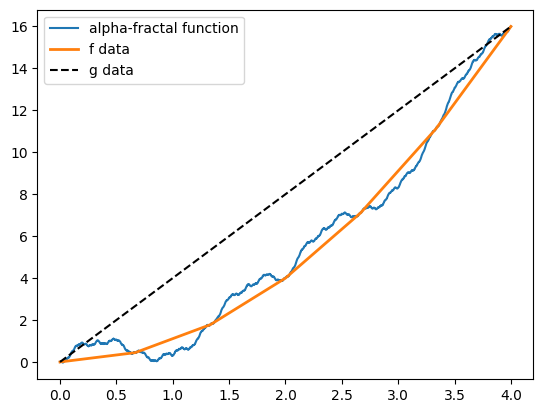

In [5]:
X = np.linspace(0, 4, 7)
f_vals = X**2 #phi(X, c)  # function values, for example f(x) = x^2

# base function values, for example linear between endpoints
g_vals = np.linspace(f_vals[0], f_vals[-1], len(X))

# alpha = 0.4  
alpha = np.array([-0.2,0.2, -0.2, -0.2, 0.2, -0.2], dtype=float)

x, y = alpha_fractal_function(X, f_vals, g_vals, alpha, 6)

plt.plot(x, y, label="alpha-fractal function")
plt.plot(X, f_vals,linewidth=2, label="f data")
plt.plot(X, g_vals, "k--", label="g data")
plt.legend()
plt.show()

In [6]:
from alpha_fractal_function import alpha_fractalize

In [7]:

def f(x):
    return x**4

def g(x):
    # Linear interpolant joining the endpoints
    return x**3

In [8]:
a = 0.0
b = 1.0

n_sub = 6                 # Number of subintervals

# alpha = 0.4               # Same alpha for every interval
alpha = [0.3, -0.2, 0.4, 0.1, -0.3, 0.2]   # Example with different alphas

n_iter = 4               # Number of RB iterations

In [9]:
x_fractal, y_fractal = alpha_fractalize(
    f,
    g,
    a,
    b,
    n_sub,
    alpha,
    n_iter,
    False
)

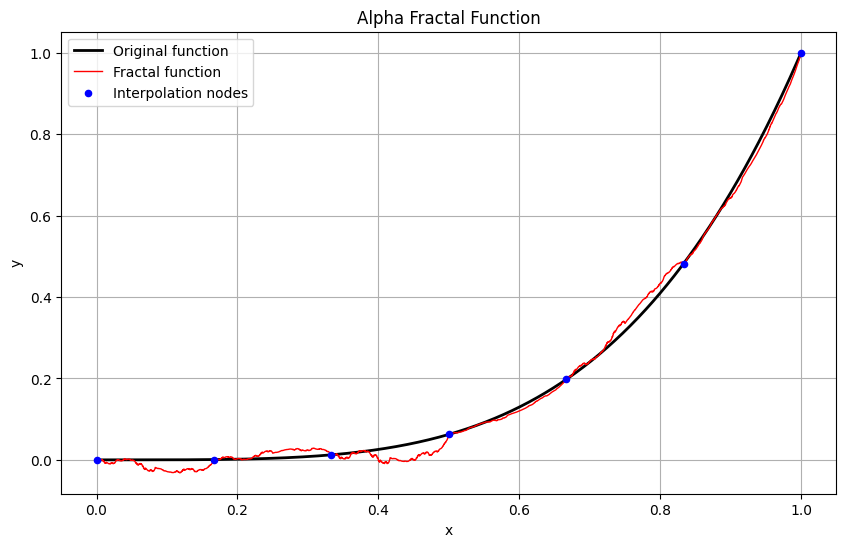

In [10]:
# Original function
xx = np.linspace(a, b, 1000)

plt.figure(figsize=(10,6))

plt.plot(xx, f(xx), 'k', lw=2, label='Original function')

plt.plot(
    x_fractal,
    y_fractal,
    color='red',
    lw=1,
    label='Fractal function'
)

plt.scatter(
    np.linspace(a, b, n_sub+1),
    f(np.linspace(a, b, n_sub+1)),
    color='blue',
    s=20,
    zorder=5,
    label='Interpolation nodes'
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Alpha Fractal Function")
plt.grid(True)
plt.legend()

plt.show()

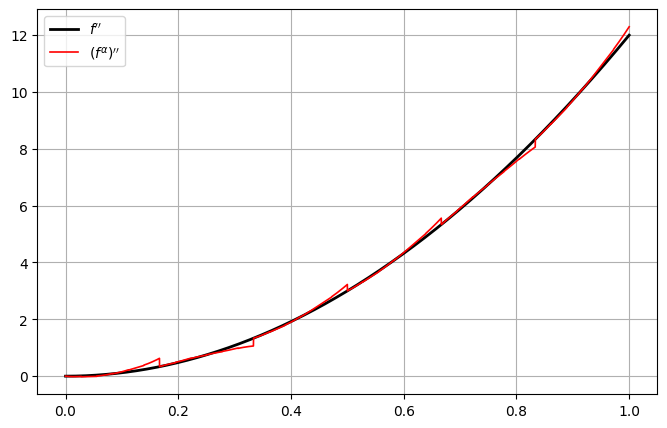

In [11]:
from alpha_fractal_function import alpha_fractalize_second_derivative


def f2(x):
    return 12*x**2

def g2(x):
    return 6*x

d_alpha = [0.0013, -0.0012, 0.001, 0.001, -0.0012, 0.0013]
# d_alpha = 0
x, y = alpha_fractalize_second_derivative(
    f2,
    g2,
    a,
    b,
    n_sub,
    d_alpha,
    n_iter,
    False
)

xx = np.linspace(0,1,1000)

plt.figure(figsize=(8,5))
plt.plot(xx, f2(xx), 'k', lw=2, label="$f''$")
plt.plot(x, y, 'r', lw=1.2, label="$(f^\\alpha)''$")
plt.grid(True)
plt.legend()
plt.show()